In [1]:
import pandas as pd
import numpy as np
import warnings
import matplotlib.pyplot as plt
import matplotlib.transforms as transforms
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.cluster import KMeans, DBSCAN  
from sklearn.neighbors import NearestNeighbors
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from kneed import KneeLocator

warnings.filterwarnings('ignore')

In [2]:
"""Utility functions""" # UTILS

def plot_singular_values(singular_values, thresh=None):
    """Bar chart of raw singular values."""
    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(1, len(singular_values) + 1)
    bars = ax.bar(x, singular_values, color='steelblue', edgecolor='none', alpha=0.85)

    if thresh is not None:
        ax.axvline(thresh, linestyle='--', lw=2, color='tab:orange', label=f'Threshold SV: {thresh}')
        ax.legend(fontsize=11)

    # Annotate top 10
    for i in range(min(10, len(singular_values))):
        ax.text(x[i], singular_values[i] + singular_values[0]*0.01,
                f'{singular_values[i]:.2f}', ha='center', va='bottom', fontsize=8, color='navy')

    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlabel('Singular Value Index', fontsize=12)
    ax.set_ylabel('Singular Value Magnitude', fontsize=12)
    fig.suptitle('Singular Values of TF-IDF Matrix (LSA)', fontsize=14, weight='bold')
    plt.tight_layout()
    return fig, ax

def plot_principal_components(X_transformed, W, column_1, column_2, margin=0.05,
                 hue=None, vals=None, figsize=(16, 8), wspace=0.03,
                 palette='default'):
    """
    Plot the principal components given X_transformed, W

    Parameters
    ----------
    X_transformed : pandas Data Frame
        Data Frame containing the tranformed feature vectors

    W : pandas Data Frame
        The data frame containing the principle components

    column_1, column 2 : str
        Principal component columns to be inspected

    margin : float, default=0.05
        Text margin on subplot 2 for prettification

    hue : numpy array, default=None
        Discriminator array to use as hue

    vals : list, default=None
        Specify to focus on specific hue values for pair plot.

    figsize : tuple, default=(16, 5)
        Specify the figure size of the lsa analysis plot

    wspace : float, default=0.03
        Specify the horizontal space between subplots

    palette : list of rgb, default='default'
        palette to use for plotting

    Returns
    -------
    fig, axes : matplotlib Figure and Axes
        Figure and axes of the PC analysis
    """
    # Set color palette
    if palette == 'default':
        palette = sns.color_palette('tab10')

    # Initialize figure
    fig, axes = plt.subplots(1, 2, figsize=figsize,
                             gridspec_kw={'wspace': wspace})

    # Set vals if not specified
    if vals is None:
        if hue is not None:
            vals = set(hue)

    # Plot word scatter plot for first 2 W's
    if hue is not None:
        for i, val in enumerate(vals):
            axes[0].plot(X_transformed.loc[hue == val, column_1],
                         X_transformed.loc[hue == val, column_2], 'o',
                         color=palette[i],
                         label=val)
        axes[0].legend()
    else:
        axes[0].plot(X_transformed.loc[:, column_1], X_transformed.loc[:, column_2], 'o')

    # Set axis labels
    axes[0].set_xlabel(column_1, fontsize=12)
    axes[0].set_ylabel(column_2, fontsize=12)

    # Remove spines
    for spine in ['top', 'right']:
        axes[0].spines[spine].set_visible(False)

    # Get lsas
    W = W.T
    lsas = np.append(W.loc[:, [column_1]],
                     W.loc[:, [column_2]],
                     axis=1)

    # Compute for weights, rank, then get indices
    weights = np.linalg.norm(lsas, axis=1)
    indices = weights.argsort()[-20:]

    # Get features
    features = W.index

    # Iterate through all top features
    for feature, vec in zip(features[indices], lsas[indices]):
        # Draw vector representation
        axes[1].annotate('', xy=(vec[0], vec[1]),  xycoords='data',
                         xytext=(0, 0), textcoords='data',
                         arrowprops=dict(facecolor=palette[0],
                                         edgecolor='none'))

        # Draw corresponding feature
        axes[1].text(vec[0], vec[1], feature, ha='center', color=palette[1],
                     fontsize=12, weight='bold', zorder=10)

        # Adjust xlim and ylim
        xlim = [min(0, np.min(W.loc[:, column_1])), 
                max(0, np.max(W.loc[:, column_1]))]
        xlim_range = xlim[1] - xlim[0]
        
        ylim = [min(0, np.min(W.loc[:, column_2])), 
                max(0, np.max(W.loc[:, column_2]))]
        ylim_range = ylim[1] - ylim[0]
        
        axes[1].set_xlim(xlim[0] - xlim_range*margin,
                         xlim[1] + xlim_range*margin)
        axes[1].set_ylim(ylim[0] - ylim_range*margin,
                         ylim[1] + ylim_range*margin)

        # Off axis for the vector plot
        axes[1].tick_params(axis='both',which='both',top=False, bottom=False,
                            labelbottom=False, labelleft=False, left=False)
    
    # Draw faint origin lines to anchor the vectors visually
    axes[1].axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5, zorder=0)
    axes[1].axvline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5, zorder=0)
    
    # Set axis labels
    axes[1].set_xlabel(column_1, fontsize=12)
    axes[1].set_ylabel(column_2, fontsize=12)

    # Remove spines
    for spine in ['top', 'right', 'left', 'bottom']:
        axes[1].spines[spine].set_visible(False)

    return fig, axes


def plot_topic_vector(term_topic_matrix, column, num_terms=20):
    """Return a plot of the weights of the topic vector with largest
    magnitude"""
    fig, ax = plt.subplots(figsize=(8, 6))
    (term_topic_matrix.loc[
        term_topic_matrix[column].abs().nlargest(num_terms).index[::-1], column
        ]
                      .plot(kind='barh'))

    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlabel("Weight", fontsize=12)
    ax.set_ylabel("Term", fontsize=12)

    fig.suptitle(column, fontsize=14, weight='bold')
    
    return fig, ax

def plot_variance_cumulative(variance_ratio, tol=0.90):
    """Cumulative variance explained plot (normalized to captured variance)."""
    
    # Normalize the cumulative variance so the max is exactly 1.0
    cumvar = np.cumsum(variance_ratio)
    normalized_cumvar = cumvar / np.sum(variance_ratio)
    
    thresh = int(np.argmax(normalized_cumvar >= tol)) + 1

    fig, ax = plt.subplots(figsize=(10, 6))
    
    # Plot the normalized cumulative variance
    ax.plot(range(0, len(normalized_cumvar) + 1), [0] + normalized_cumvar.tolist(),
            lw=3, marker='o', markersize=4, color='steelblue', label='Cumulative Captured Variance')
    
    ax.axvline(thresh, linestyle='-', lw=2.5, color='tab:orange', label=f'{int(tol*100)}% threshold @ SV {thresh}')
    ax.axhline(tol, linestyle=':', lw=1.5, color='gray')

    trans = transforms.blended_transform_factory(ax.transData, ax.transAxes)
    ax.text(thresh + 1, 0.08, f'SVs needed: {thresh}',
            color='tab:orange', weight='bold', fontsize=11, transform=trans)

    # Set x-axis limit dynamically based on the number of SVs you generated
    ax.set_xlim(0, len(normalized_cumvar))
    ax.set_ylim(0, 1.05)
    
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlabel('Number of SVs', fontsize=12)
    ax.set_ylabel('Cumulative % of Captured Variance', fontsize=12)
    ax.legend(fontsize=11)
    
    fig.suptitle(f'Cumulative Captured Variance vs. Number of SVs', fontsize=14, weight='bold')
    plt.tight_layout()
    
    return fig, ax, thresh

def plot_variance_per_sv(variance_ratio, n_show=40):
    """Individual variance contribution per singular vector."""
    fig, ax = plt.subplots(figsize=(12, 5))
    x = np.arange(1, n_show + 1)
    ax.bar(x, variance_ratio[:n_show] * 100, color='teal', edgecolor='none', alpha=0.85)
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlabel('Singular Vector Index', fontsize=12)
    ax.set_ylabel('Variance Explained (%)', fontsize=12)
    fig.suptitle(f'Individual Variance per Singular Vector (top {n_show})', fontsize=14, weight='bold')
    plt.tight_layout()
    return fig, ax

def plot_scree(singular_values, n_show=40):
    """Scree plot – elbow detection aid."""
    diffs = np.diff(singular_values[:n_show])
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].plot(range(1, n_show + 1), singular_values[:n_show],
                 marker='o', lw=2, color='steelblue')
    axes[0].spines[['top', 'right']].set_visible(False)
    axes[0].set_title('Scree Plot (Singular Values)', fontsize=13, weight='bold')
    axes[0].set_xlabel('SV Index')
    axes[0].set_ylabel('Singular Value')

    axes[1].plot(range(2, n_show + 1), diffs, marker='o', lw=2, color='tomato')
    axes[1].axhline(0, linestyle='--', color='gray', lw=1)
    axes[1].spines[['top', 'right']].set_visible(False)
    axes[1].set_title('First Difference of Singular Values', fontsize=13, weight='bold')
    axes[1].set_xlabel('SV Index')
    axes[1].set_ylabel('Δ Singular Value')
    plt.tight_layout()
    return fig, axes

def plot_energy_ratio(energy_ratio, tol=0.90):
    """Original cumulative energy plot (kept for compatibility)."""
    cumulative = np.cumsum(energy_ratio)
    thresh = int(np.argmax(cumulative >= tol)) + 1

    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(range(0, len(cumulative) + 1), [0] + cumulative.tolist(), lw=3, marker='o')
    ax.axvline(thresh, linestyle='-', lw=2.5, color='tab:orange')

    trans = transforms.blended_transform_factory(ax.transData, ax.transAxes)
    ax.text(1.05*thresh, 0.05, f'Number of SVs: {thresh}',
            color='tab:orange', weight='bold', fontsize=12, transform=trans)

    ax.set_ylim(0, 1)
    ax.set_xlim(0, len(cumulative))
    ax.spines[['top', 'right']].set_visible(False)
    ax.set_xlabel('Number of SVs', fontsize=12)
    ax.set_ylabel('Cumulative Energy Preserved', fontsize=12)
    fig.suptitle('Cumulative Energy Preserved vs Number of SVs', fontsize=14, weight='bold')
    plt.tight_layout()
    return fig, ax, thresh

In [3]:
df = pd.read_csv('data/amazon_bestsellers_reviews_cleaned.csv')
df.head(3)

,department,product_index,product_name,product_url,reviewer,rating,date,verified,title,body,...,text_for_lsa,is_helpful,location,rating_mid_dist,title_len,body_len,word_count,avg_word_len,sentiment_strength,sentiment_is_positive
0,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,Sridhar Mani,5,2026-03-17,Verified Purchase,Best-in-Class Quality and Sound,These Apple EarPods with USB-C are truly best ...,...,best class quality sound apple earpods usb c t...,1,United States,2,31,557,61,9.131148,0.9876,1
1,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,A.S,5,2026-04-11,Verified Purchase,Great Sound and Comfort,"I bought these for my son, who prefers traditi...",...,great sound comfort bought son prefers traditi...,1,United States,2,23,495,43,11.511628,0.9547,1
2,Electronics,2,"Apple EarPods Headphones with USB-C Plug, Wire...",https://www.amazon.com/dp/B0DCH8VDXF,Amazon_Customer,5,2026-04-10,Verified Purchase,"The $9 Audiophile Secret: Small Dongle, Big Pr...",Lets be honest: nobody actually wants to live ...,...,audiophile secret small dongle big practicalit...,1,United States,2,56,1369,135,10.140741,0.9857,1


In [4]:
# Split the data, stratifying by target variable to maintain class balance
df_train, df_test = train_test_split(
    df, 
    test_size=0.2, 
    stratify=df['is_helpful'], 
    random_state=67
)

# Create copies to avoid SettingWithCopyWarning
df_train = df_train.copy()
df_test = df_test.copy()

print(f"Train shape: {df_train.shape}")
print(f"Test shape: {df_test.shape}")

Train shape: (1210, 23)
Test shape: (303, 23)


## Why SVD Instead of PCA?

| Criterion | SVD (TruncatedSVD) | PCA |
|---|---|---|
| **Input format** | Sparse matrices (TF-IDF) natively | Requires dense matrix |
| **Centering** | Not required — works on raw TF-IDF | Requires zero-mean centering, which destroys sparsity |
| **Memory** | O(k) — only top-k singular vectors | O(n²) covariance matrix |
| **Speed** | Randomised SVD in sklearn is ~10× faster on large text data | Scales poorly |
| **Interpretability** | Singular values directly express "energy" in latent topics (LSA) | Eigenvalues are a derived quantity |
| **Negative values** | Allowed — captures semantic opposition | Same, but direction is less interpretable for text |

**Conclusion:** For sparse, high-dimensional TF-IDF matrices, `TruncatedSVD` is the
mathematically appropriate and computationally efficient choice. PCA would require
densifying the matrix, introducing prohibitive memory costs. This specific use of SVD
on TF-IDF is known as **Latent Semantic Analysis (LSA)**.

In [8]:
# TF-IDF Vectorization
tfidf_vectorizer = TfidfVectorizer(token_pattern=r'\w+', min_df=5)
tfidf_train = tfidf_vectorizer.fit_transform(df_train['text_for_lsa'])
tfidf_test = tfidf_vectorizer.transform(df_test['text_for_lsa'])
print(f"TF-IDF Train matrix shape: {tfidf_train.shape}")
print(f"TF-IDF Test matrix shape: {tfidf_test.shape}")
print(f"Sparsity Train: {1 - tfidf_train.nnz / (tfidf_train.shape[0]*tfidf_train.shape[1]):.4f}")
print(f"Sparsity Test: {1 - tfidf_test.nnz / (tfidf_test.shape[0]*tfidf_test.shape[1]):.4f}")

TF-IDF Train matrix shape: (1210, 1754)
TF-IDF Test matrix shape: (303, 1754)
Sparsity Train: 0.9820
Sparsity Test: 0.9812


In [6]:
# 5. LSA (Latent Semantic Analysis) via TruncatedSVD
svd = TruncatedSVD(n_components=100, random_state=42)
lsa_train = svd.fit_transform(tfidf_train)
lsa_test = svd.transform(tfidf_test)
singular_values = svd.singular_values_
variance_explained = svd.explained_variance_ratio_

print(f"Top 10 singular values: {np.round(singular_values[:10], 4)}")
print(f"Top 10 variance ratios: {np.round(variance_explained[:10], 4)}")
print(f"Total variance explained (100 SVs): {variance_explained.sum():.4f}")

Top 10 singular values: [7.009  4.0523 3.5248 3.4448 3.3053 3.0858 3.0047 2.9579 2.8809 2.8241]
Top 10 variance ratios: [0.0039 0.014  0.0107 0.0102 0.0094 0.0082 0.0077 0.0075 0.0071 0.0068]
Total variance explained (100 SVs): 0.3883


## Singular Value Analysis

The following four plots examine the singular values from different angles:
1. **Raw singular value magnitudes** – how much signal each latent dimension captures.
2. **Cumulative variance explained** – how quickly variance accumulates; used to pick the truncation threshold.
3. **Per-SV variance contribution** – the individual "weight" of each latent dimension.
4. **Scree plot + first differences** – visual elbow to guide dimensionality selection.

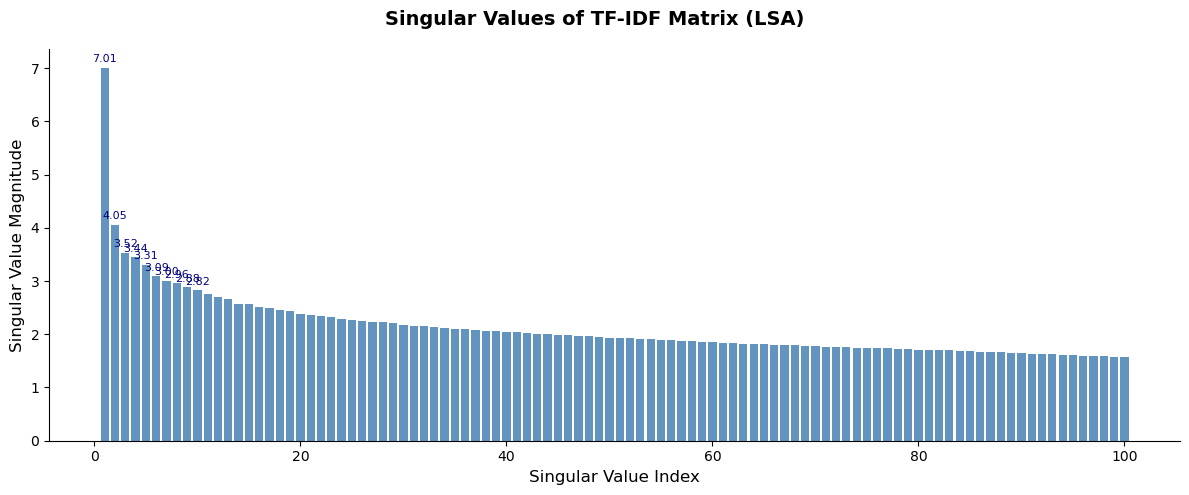


--- Singular Value Insights ---
  Largest SV  : 7.0090
  Smallest SV : 1.5758
  Ratio (σ1/σk): 4.45x
  Top-5 SVs   : [7.009  4.0523 3.5248 3.4448 3.3053]
  Interpretation: A steep drop from σ1 suggests a few dominant latent topics;
  a gradual decay indicates distributed topic structure across reviews.


In [7]:
# ── Graph 1: Raw Singular Values ────────────────────────────────────────────
fig1, ax1 = plot_singular_values(singular_values)
plt.show()

print("\n--- Singular Value Insights ---")
print(f"  Largest SV  : {singular_values[0]:.4f}")
print(f"  Smallest SV : {singular_values[-1]:.4f}")
print(f"  Ratio (σ1/σk): {singular_values[0]/singular_values[-1]:.2f}x")
print(f"  Top-5 SVs   : {np.round(singular_values[:5], 4)}")
print("  Interpretation: A steep drop from σ1 suggests a few dominant latent topics;")
print("  a gradual decay indicates distributed topic structure across reviews.")

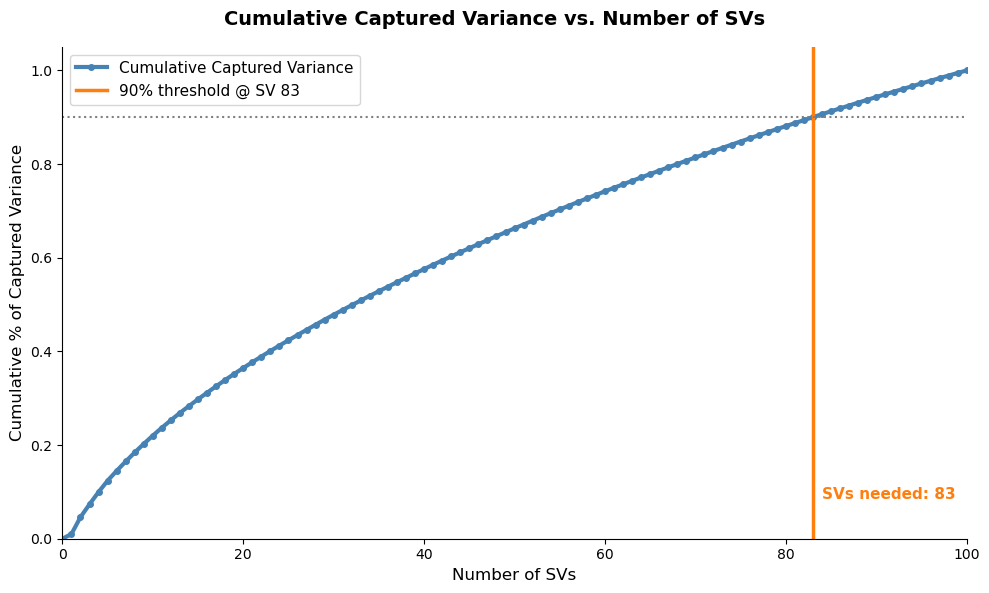


SVs needed to explain 90% variance: 83
Variance explained by first SV     : 0.39%
Variance explained by top-83 SVs : 34.96%


In [8]:
# ── Graph 2: Cumulative Variance Explained (variance, not energy) ────────────
fig2, ax2, thresh = plot_variance_cumulative(variance_explained, tol=0.90)
plt.show()

print(f"\nSVs needed to explain 90% variance: {thresh}")
print(f"Variance explained by first SV     : {variance_explained[0]*100:.2f}%")
print(f"Variance explained by top-{thresh} SVs : {variance_explained[:thresh].sum()*100:.2f}%")

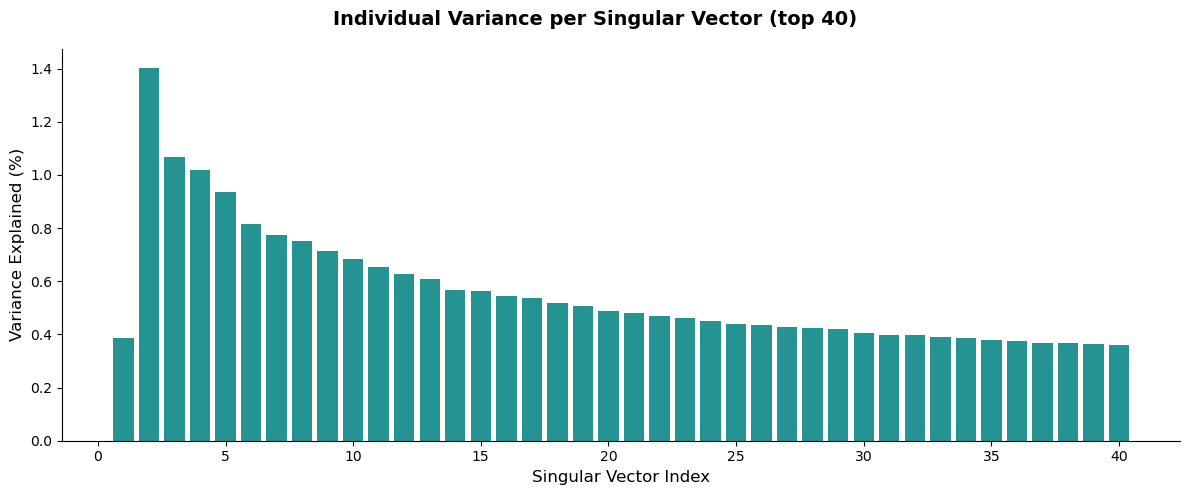

In [9]:
# ── Graph 3: Per-SV Variance ─────────────────────────────────────────────────
fig3, ax3 = plot_variance_per_sv(variance_explained, n_show=40)
plt.show()

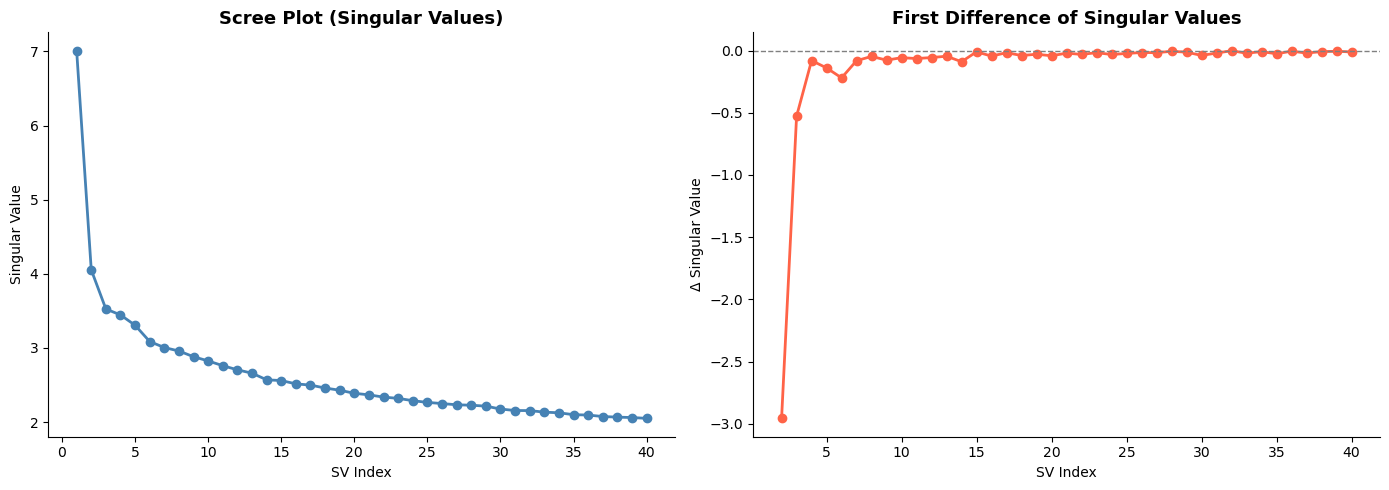


Scree Insight:
  The elbow in the first-difference plot marks where marginal information
  gain from additional SVs diminishes rapidly — a natural cut-point for
  dimensionality reduction beyond the 90%-variance threshold.


In [10]:
# ── Graph 4: Scree Plot ───────────────────────────────────────────────────────
fig4, axes4 = plot_scree(singular_values, n_show=40)
plt.show()

print("\nScree Insight:")
print("  The elbow in the first-difference plot marks where marginal information")
print("  gain from additional SVs diminishes rapidly — a natural cut-point for")
print("  dimensionality reduction beyond the 90%-variance threshold.")

In [11]:
# Truncate LSA to 90%-variance threshold
thresh = max(thresh, 2)
truncated_lsa_train = lsa_train[:, :thresh]
truncated_lsa_test = lsa_test[:, :thresh]
print(f"Truncated LSA Train shape: {truncated_lsa_train.shape}")
print(f"Truncated LSA Test shape: {truncated_lsa_test.shape}")
print(f"Using {thresh} latent semantic dimensions for clustering.")

Truncated LSA Train shape: (1210, 83)
Truncated LSA Test shape: (303, 83)
Using 83 latent semantic dimensions for clustering.


In [12]:
# 1. Extract the feature names (the actual words) from the TF-IDF Vectorizer
vocab = tfidf_vectorizer.get_feature_names_out()

# 2. Extract the components (the W matrix / V^T) from the fitted SVD
# Make sure to slice it to your truncation threshold (e.g., 50 components)
topic_word_weights = svd.components_[:thresh, :]

# 3. Build the W DataFrame
df_W = pd.DataFrame(
    topic_word_weights,
    columns=vocab,
    index=[f'LSA {i + 1}' for i in range(thresh)]
)

# Optional: Transpose it so Words are rows and Topics are columns (much easier to read!)
df_W_transposed = df_W.T

print(f"W Matrix Shape: {df_W_transposed.shape} (Words x Topics)")
df_W_transposed.head()

W Matrix Shape: (1706, 83) (Words x Topics)


,LSA 1,LSA 2,LSA 3,LSA 4,LSA 5,LSA 6,LSA 7,LSA 8,LSA 9,LSA 10,...,LSA 74,LSA 75,LSA 76,LSA 77,LSA 78,LSA 79,LSA 80,LSA 81,LSA 82,LSA 83
ability,0.003732,0.005336,-0.001979,-0.006133,0.004898,-0.002986,-0.002619,-0.003526,-0.003926,0.005693,...,-0.001401,0.012427,0.003012,0.011082,0.001091,-0.000464,0.010075,0.002973,-0.002929,0.006008
able,0.022013,0.015364,0.000857,-0.020631,0.005600,-0.005583,0.007907,-0.000780,-0.012447,0.005772,...,0.083118,0.009632,0.023487,0.014076,0.005612,-0.018922,-0.001573,0.025939,0.032007,0.016297
absolute,0.004987,0.004377,-0.009643,0.001404,0.005021,0.005651,-0.003847,-0.003562,-0.004326,0.007987,...,0.000028,0.010239,-0.003827,0.005866,0.006723,0.000179,0.011910,-0.005132,-0.004011,0.003118
absolutely,0.027740,0.003875,-0.046341,0.025194,0.017220,-0.032481,0.015595,0.017253,0.002077,-0.019648,...,0.038883,0.014307,-0.038655,-0.053252,-0.072607,-0.058482,0.074011,0.001196,0.107405,0.029521
absorbent,0.007057,-0.001883,0.000095,0.003860,0.004222,0.009739,0.000140,0.000024,-0.005445,-0.002759,...,0.011199,0.019628,-0.003994,-0.011070,-0.028946,0.017511,0.011322,-0.014059,-0.014479,0.008996


In [13]:
# ── 1. Define Clusters (Fit on Train, Predict on Test) ───────────────────────
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
train_clusters = kmeans.fit_predict(truncated_lsa_train)
test_clusters = kmeans.predict(truncated_lsa_test)

# =============================================================================
# ── Build final ML-ready feature DataFrame (TRAIN SET) ───────────────────────
# =============================================================================

# LSA columns
lsa_cols = [f'lsa_{i}' for i in range(truncated_lsa_train.shape[1])]
df_lsa_train = pd.DataFrame(truncated_lsa_train, columns=lsa_cols, index=df_train.index)

# Structured numerical features (NO helpful_votes — data leakage)
structured_features = ['rating', 'rating_mid_dist', 'title_len',
                       'body_len', 'word_count', 'avg_word_len',
                       'sentiment_strength', 'sentiment_is_positive']

df_structured_train = df_train[structured_features].copy()

# (Optional) Add the cluster labels if you decided to keep them
# df_structured_train['cluster_kmeans'] = train_clusters

# Fix any division-by-zero infinities from avg_word_len
df_structured_train.replace([np.inf, -np.inf], 0, inplace=True)

# Target
df_target_train = df_train[['is_helpful']].copy()

# Concatenate everything
df_train_final = pd.concat([df_lsa_train, df_structured_train, df_target_train], axis=1).fillna(0)

print(f"TRAIN dataset shape: {df_train_final.shape}")


# =============================================================================
# ── Build final ML-ready feature DataFrame (TEST SET) ────────────────────────
# =============================================================================

# LSA columns
df_lsa_test = pd.DataFrame(truncated_lsa_test, columns=lsa_cols, index=df_test.index)

# Structured numerical features
df_structured_test = df_test[structured_features].copy()

# (Optional) Add the cluster labels if you decided to keep them
# df_structured_test['cluster_kmeans'] = test_clusters

# Fix any division-by-zero infinities from avg_word_len
df_structured_test.replace([np.inf, -np.inf], 0, inplace=True)

# Target
df_target_test = df_test[['is_helpful']].copy()

# Concatenate everything
df_test_final = pd.concat([df_lsa_test, df_structured_test, df_target_test], axis=1).fillna(0)

print(f"TEST dataset shape: {df_test_final.shape}")

TRAIN dataset shape: (1210, 92)
TEST dataset shape: (303, 92)


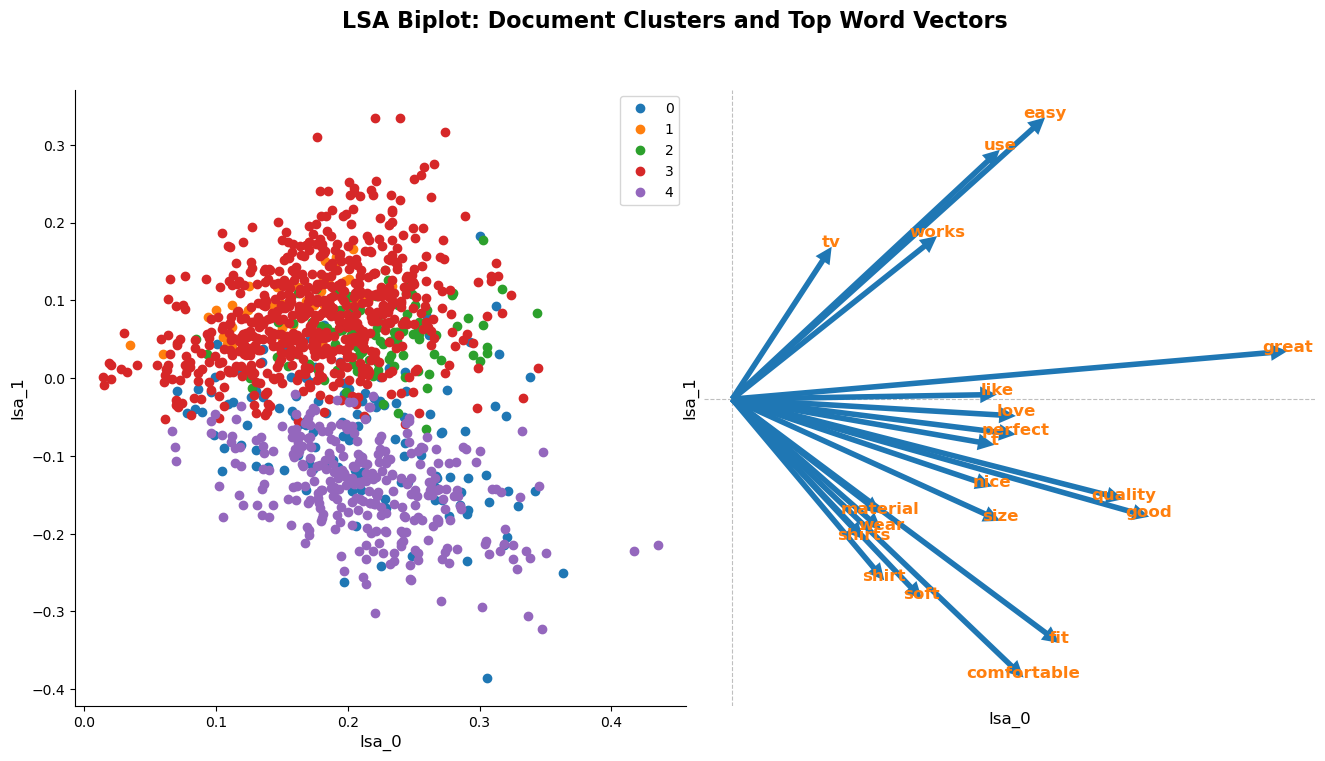

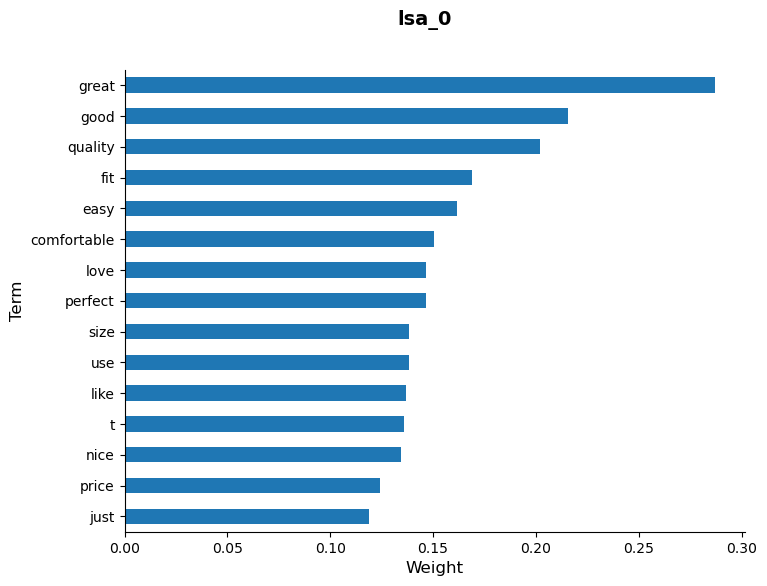

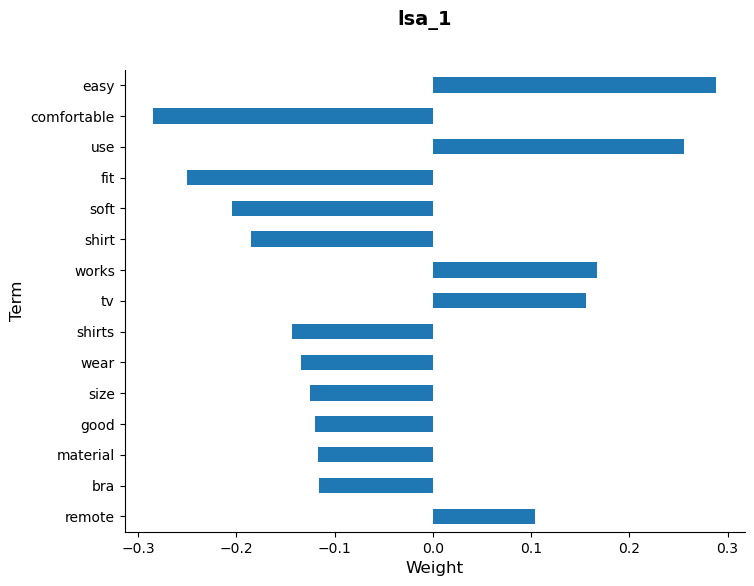

In [14]:
# ==========================================
# 1. Align the W Matrix Index
# ==========================================
# In our previous step, df_lsa_train had columns like 'lsa_0', 'lsa_1'.
# We must ensure df_W's index uses these exact same names!
df_W.index = [f'lsa_{i}' for i in range(thresh)]

# term_topic_matrix is just the transposed W matrix (Words as rows, Topics as columns)
term_topic_matrix = df_W.T


# ==========================================
# 2. Plot the Principal Components (Biplot)
# ==========================================
# We will look at the first two semantic dimensions: lsa_0 and lsa_1.
# We can use your K-Means clusters as the 'hue' to see how the clusters 
# separate along these two dimensions!

fig_pc, axes_pc = plot_principal_components(
    X_transformed=df_lsa_train, 
    W=df_W, 
    column_1='lsa_0', 
    column_2='lsa_1', 
    hue=train_clusters,   # Color the points by K-Means cluster
    figsize=(16, 8)
)
# Add a nice title
fig_pc.suptitle("LSA Biplot: Document Clusters and Top Word Vectors", fontsize=16, weight='bold')
plt.show()


# ==========================================
# 3. Plot the Topic Vectors (Bar Charts)
# ==========================================
# Let's inspect the top 15 words driving the first two LSA topics

# Plot for LSA Dimension 0
fig_tv0, ax_tv0 = plot_topic_vector(
    term_topic_matrix=term_topic_matrix, 
    column='lsa_0', 
    num_terms=15
)
plt.show()

# Plot for LSA Dimension 1
fig_tv1, ax_tv1 = plot_topic_vector(
    term_topic_matrix=term_topic_matrix, 
    column='lsa_1', 
    num_terms=15
)
plt.show()

## Clustering: K-Means + DBSCAN + Hierarchical Agglomerative

Three complementary clustering paradigms are applied to the LSA-reduced space:

| Method | Paradigm | Key strength |
|---|---|---|
| **K-Means** | Partition-based | Fast; identifies globular centroids |
| **DBSCAN** | Density-based | Detects arbitrary shapes; labels noise as -1 |
| **Agglomerative** | Hierarchical (representative) | Reveals nested cluster structure via dendrogram |

In [15]:
# Clustering semantic features
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters_km = kmeans.fit_predict(truncated_lsa_train)
df_train['cluster_kmeans'] = clusters_km
df_train.head()

print("K-Means cluster distribution:")
print(pd.Series(clusters_km).value_counts().sort_index())

K-Means cluster distribution:
0    136
1     45
2     99
3    627
4    303
Name: count, dtype: int64


### DBSCAN — Density-Based Spatial Clustering

DBSCAN groups points that are tightly packed together and marks low-density points as noise
(label = -1). Unlike K-Means it does **not** require specifying k in advance.
The `eps` (neighbourhood radius) is estimated from the k-NN distance plot.

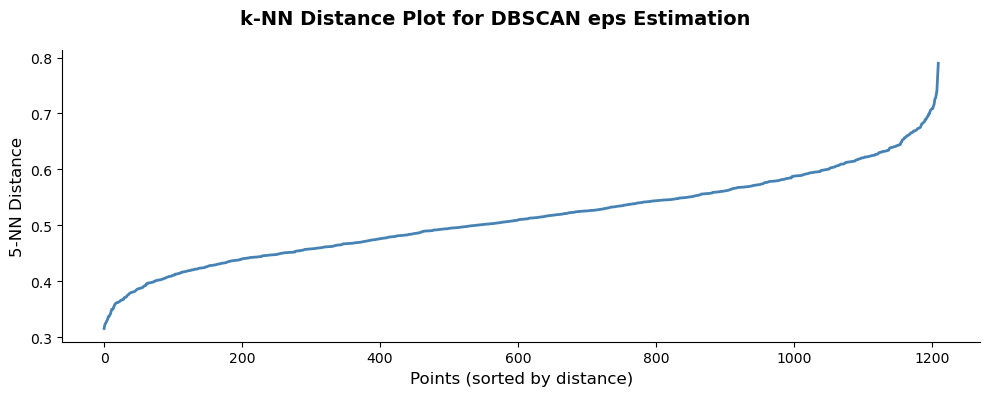

Estimated eps (5th percentile of 5-NN distances): 0.6688


In [16]:
# ── DBSCAN: Estimate eps via k-NN distance plot ───────────────────────────────

k = 5
nbrs = NearestNeighbors(n_neighbors=k, algorithm='ball_tree').fit(truncated_lsa_train)
distances, _ = nbrs.kneighbors(truncated_lsa_train)
knn_dists = np.sort(distances[:, k-1])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(knn_dists, lw=2, color='steelblue')
ax.set_xlabel('Points (sorted by distance)', fontsize=12)
ax.set_ylabel(f'{k}-NN Distance', fontsize=12)
ax.spines[['top', 'right']].set_visible(False)
fig.suptitle('k-NN Distance Plot for DBSCAN eps Estimation', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

# EPS
kneel = KneeLocator(range(len(knn_dists)), knn_dists, curve='convex', direction='increasing')
eps_est = knn_dists[kneel.knee]
print(f"Estimated eps (5th percentile of {k}-NN distances): {eps_est:.4f}")

In [17]:
# ── Run DBSCAN ───────────────────────────────────────────────────────────────
dbscan = DBSCAN(eps=eps_est, min_samples=5, metric='euclidean', n_jobs=-1)
clusters_db = dbscan.fit_predict(truncated_lsa_train)
df_train['cluster_dbscan'] = clusters_db

n_clusters_db = len(set(clusters_db)) - (1 if -1 in clusters_db else 0)
n_noise_db    = (clusters_db == -1).sum()

print(f"DBSCAN found {n_clusters_db} cluster(s) + {n_noise_db} noise points")
print("Cluster distribution (−1 = noise):")
print(pd.Series(clusters_db).value_counts().sort_index())

DBSCAN found 1 cluster(s) + 6 noise points
Cluster distribution (−1 = noise):
-1       6
 0    1204
Name: count, dtype: int64


### Hierarchical Agglomerative Clustering (HAC)

HAC merges the two closest clusters at each step using **Ward linkage** (minimises
within-cluster variance). The resulting dendrogram gives a multi-resolution view of the
cluster structure — useful for choosing the number of clusters without pre-specifying k.

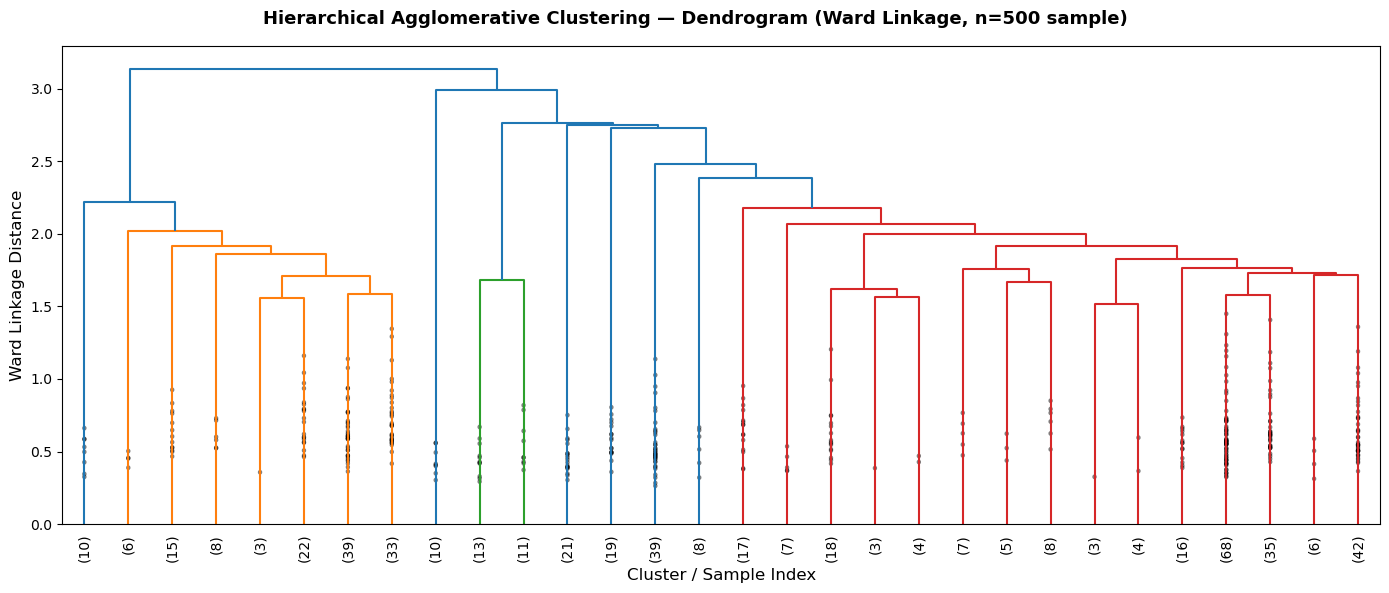

HAC cluster distribution (sample, 5 clusters):
1    136
2     10
3     24
4     21
5    309
Name: count, dtype: int64


In [18]:
# ── Hierarchical Agglomerative Clustering ────────────────────────────────────
# Subsample for dendrogram readability (linkage on full dataset is expensive)
np.random.seed(42)
sample_idx  = np.random.choice(len(truncated_lsa_train), size=min(500, len(truncated_lsa_train)), replace=False)
sample_lsa  = truncated_lsa_train[sample_idx]

Z = linkage(sample_lsa, method='ward', metric='euclidean')

fig, ax = plt.subplots(figsize=(14, 6))
dendrogram(Z, ax=ax, truncate_mode='lastp', p=30,
           leaf_rotation=90, leaf_font_size=10, show_contracted=True)
ax.set_xlabel('Cluster / Sample Index', fontsize=12)
ax.set_ylabel('Ward Linkage Distance', fontsize=12)
fig.suptitle('Hierarchical Agglomerative Clustering — Dendrogram (Ward Linkage, n=500 sample)',
             fontsize=13, weight='bold')
plt.tight_layout()
plt.show()

# Cut dendrogram at 5 clusters to match K-Means for comparability
hac_labels_sample = fcluster(Z, t=5, criterion='maxclust')
print(f"HAC cluster distribution (sample, 5 clusters):")
print(pd.Series(hac_labels_sample).value_counts().sort_index())

In [19]:
# Apply HAC to full dataset via linkage on full matrix
MAX_HAC_ROWS = 10_000
if len(truncated_lsa_train) > MAX_HAC_ROWS:
    print(f"Dataset too large for full HAC linkage ({len(truncated_lsa_train)} rows); skipping full HAC clustering.")
else:
    Z_full = linkage(truncated_lsa_train, method='ward', metric='euclidean')
    clusters_hac = fcluster(Z_full, t=5, criterion='maxclust') - 1  # 0-indexed

df_train['cluster_hac'] = clusters_hac

print("HAC full-dataset cluster distribution:")
print(pd.Series(clusters_hac).value_counts().sort_index())

HAC full-dataset cluster distribution:
0    363
1     80
2     61
3     88
4    618
Name: count, dtype: int64


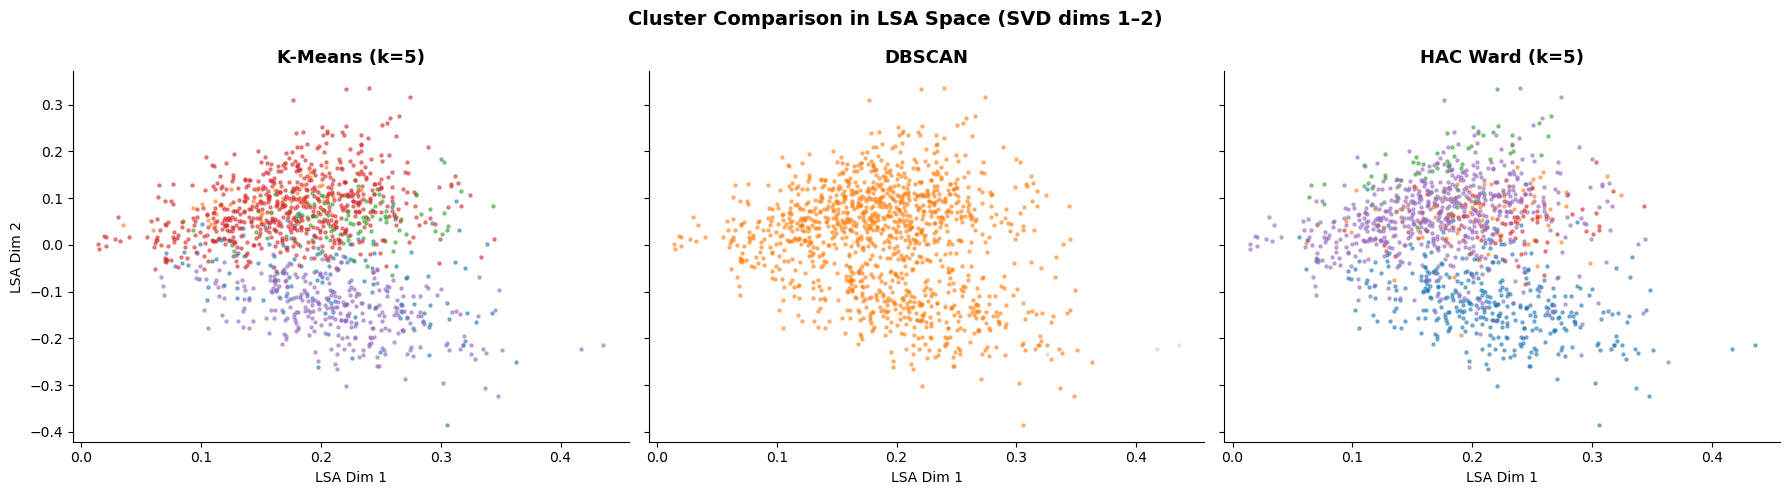

Clustering Observations:
  K-Means:       Produces balanced, globular clusters; sensitive to initialisation.
  DBSCAN:        Identifies dense review neighbourhoods; noise points may be outlier reviews.
  HAC (Ward):    Reveals hierarchical topic structure; most stable for nested themes.


In [20]:
# ── 2-D projection (SVD dim 0 vs dim 1) coloured by each method ───────────────
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharex=True, sharey=True)
palette = sns.color_palette('tab10', 10)

for ax, (labels, title) in zip(axes, [
    (clusters_km,  'K-Means (k=5)'),
    (clusters_db,  'DBSCAN'),
    (clusters_hac, 'HAC Ward (k=5)'),
]):
    unique = sorted(set(labels))
    for i, lbl in enumerate(unique):
        mask = labels == lbl
        color = 'lightgray' if lbl == -1 else palette[i % 10]
        lname = 'Noise' if lbl == -1 else f'Cluster {lbl}'
        ax.scatter(truncated_lsa_train[mask, 0], truncated_lsa_train[mask, 1],
                   color=color, s=5, alpha=0.5, label=lname)
    ax.set_title(title, fontsize=13, weight='bold')
    ax.set_xlabel('LSA Dim 1')
    ax.spines[['top', 'right']].set_visible(False)

axes[0].set_ylabel('LSA Dim 2')
plt.suptitle('Cluster Comparison in LSA Space (SVD dims 1–2)', fontsize=14, weight='bold')
plt.tight_layout()
plt.show()

print("Clustering Observations:")
print("  K-Means:       Produces balanced, globular clusters; sensitive to initialisation.")
print("  DBSCAN:        Identifies dense review neighbourhoods; noise points may be outlier reviews.")
print("  HAC (Ward):    Reveals hierarchical topic structure; most stable for nested themes.")

## Final Dataset: Fully Numerical, ML-Ready

The final feature table is assembled from:
- **LSA features** (truncated SVD dimensions) — semantic representation of review text
- **Encoded structured features** — rating, date parts, location frequency, text lengths
- **Cluster labels** — from K-Means, DBSCAN, and HAC
- **Target** — `is_helpful` (binary)

`helpful_votes` is **excluded as a feature** (data leakage guard) but remains in `df` for auditing.

In [21]:
# ── Sanity Check ─────────────────────────────────────────────────────────────
print(f"\nAll Train dtypes numerical? {all(df_train_final.dtypes.apply(lambda x: np.issubdtype(x, np.number)))}")
print(f"All Test dtypes numerical? {all(df_test_final.dtypes.apply(lambda x: np.issubdtype(x, np.number)))}")


All Train dtypes numerical? True
All Test dtypes numerical? True


In [22]:
# ── Export final datasets ────────────────────────────────────────────────────
df_train_final.to_csv("data/amazon_bestsellers_reviews_train_ml_ready.csv", index=False)
df_test_final.to_csv("data/amazon_bestsellers_reviews_test_ml_ready.csv", index=False)

print("\nExported clean Train and Test CSVs!")


Exported clean Train and Test CSVs!
